Total unique images: 182
Top 10 images with highest scores:
                            image     score
2128            n02091134_whippet  0.939449
1168           n02114712_red_wolf  0.941421
2110       n02089867_Walker_hound  0.942649
391               n01882714_koala  0.942835
2476     n02100735_English_setter  0.946421
169        n01748264_Indian_cobra  0.947951
1144  n02112706_Brabancon_griffon  0.954442
2521           n02105505_komondor  0.958928
1141           n02112350_keeshond  0.959366
7           n01491361_tiger_shark  0.960217


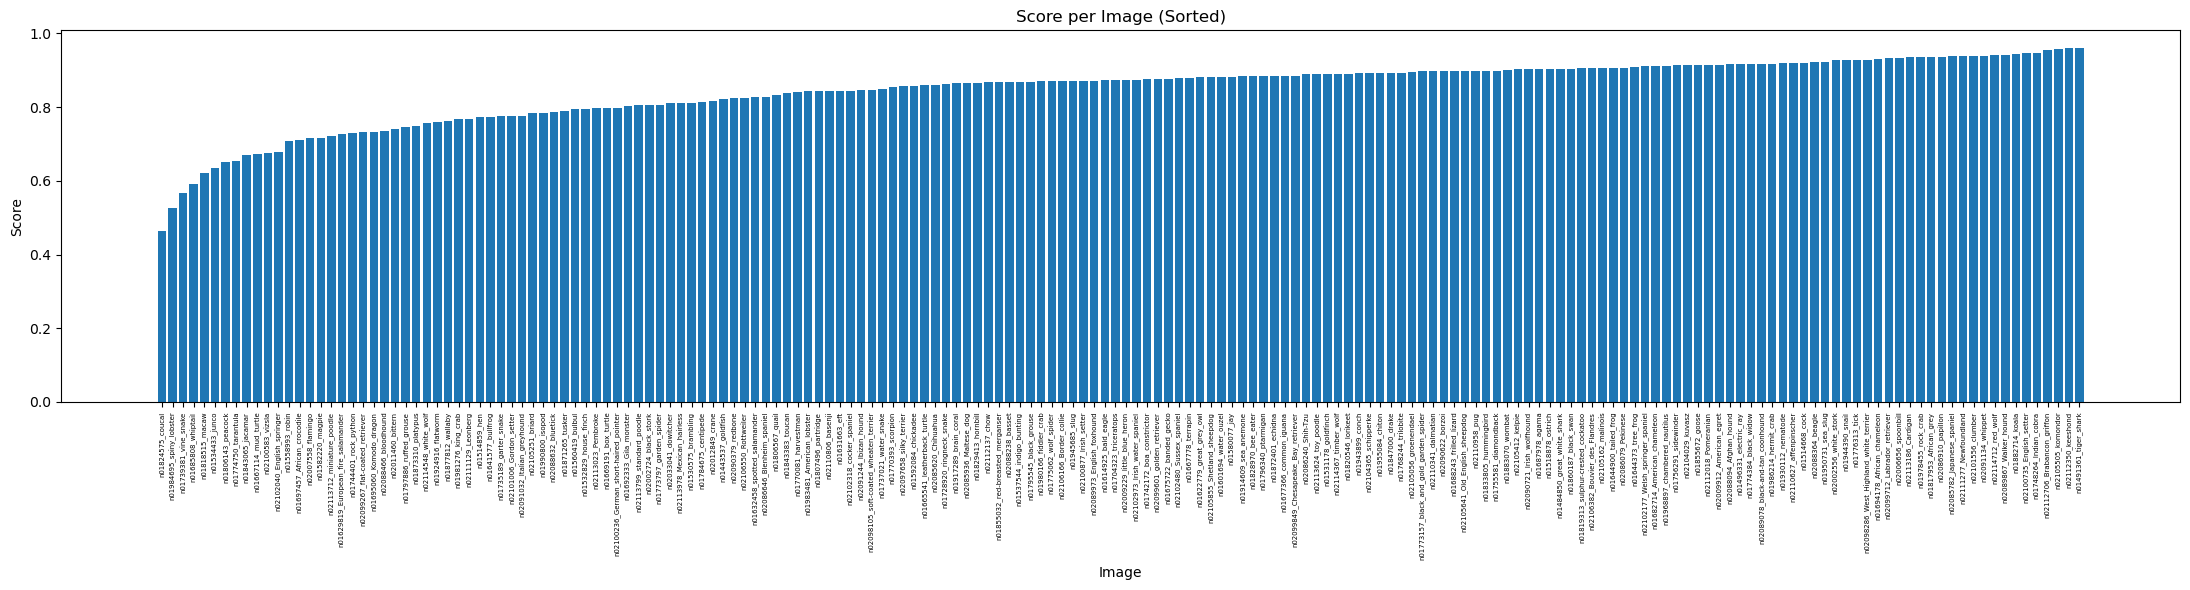

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ===============================
# Load CSV
# ===============================
file_path = "../../analysis/csvs/ALL_vggnet_triplets_merged.csv"  # adjust path if needed
df = pd.read_csv(file_path)

# ===============================
# Select columns
# ===============================
image_col = "image"
score_col = "score"

# Remove missing values
df = df[[image_col, score_col]].dropna()

# Ensure image names are strings
df[image_col] = df[image_col].astype(str)

# Keep only one row per unique image
df_unique = df.drop_duplicates(subset=image_col)

# Sort by score (ascending)
df_sorted = df_unique.sort_values(by=score_col, ascending=True)

print("Total unique images:", len(df_sorted))

print ("Top 10 images with highest scores:")
print(df_sorted.tail(10))

# ===============================
# Create bar plot
# ===============================
x = np.arange(len(df_sorted))

plt.figure(figsize=(22, 6))
plt.bar(x, df_sorted[score_col].values)

plt.xticks(x, df_sorted[image_col].values, rotation=90, fontsize=5)
plt.ylabel("Score")
plt.xlabel("Image")
plt.title("Score per Image (Sorted)")
plt.tight_layout()

plt.show()

# # ===============================
# # Optional: Save as PDF
# # ===============================
# plt.savefig("score_per_image_sorted.pdf")

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import shutil

# ===============================
# Styling: LaTeX if available, otherwise clean serif fallback
# ===============================
LATEX_AVAILABLE = shutil.which("latex") is not None

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times", "DejaVu Serif"],
    "axes.labelsize": 14,
    "axes.titlesize": 15,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

if LATEX_AVAILABLE:
    plt.rcParams.update({
        "text.usetex": True,
        "text.latex.preamble": r"\usepackage{amsmath}\usepackage{bm}",
    })
else:
    plt.rcParams.update({
        "text.usetex": False,
        "mathtext.fontset": "cm",
    })
    print("LaTeX not found -> using Matplotlib mathtext fallback.")

# ===============================
# Ask user for CSV paths
# ===============================

imagenet_path = "../../analysis/csvs/ALL_vggnet_triplets_merged.csv"
cifar100_path = "../../results/cifar100/cifar100_segmented.csv"

df_imagenet = pd.read_csv(imagenet_path)
df_cifar100 = pd.read_csv(cifar100_path)

image_col = "image"
score_col = "score"

def prepare_scores(df):
    df = df[[image_col, score_col]].dropna()
    df[image_col] = df[image_col].astype(str)
    df = df.drop_duplicates(subset=image_col)
    scores = df[score_col].astype(float).to_numpy()
    scores.sort()  # ascending
    return scores

scores_im = prepare_scores(df_imagenet)
scores_cf = prepare_scores(df_cifar100)

def add_quantile_lines(ax, scores):
    qs = [0.10, 0.50, 0.90]
    qvals = np.quantile(scores, qs)

    for q, v in zip(qs, qvals):
        ax.axhline(v, linestyle="--", linewidth=1.0)
        ax.text(
            0.02, v, f"{int(q*100)}\\%={v:.3f}" if LATEX_AVAILABLE else f"{int(q*100)}%={v:.3f}",
            va="bottom", ha="left", fontsize=11
        )

    return qvals

def plot_sorted_percentile(ax, scores, title):
    n = len(scores)
    x = (np.arange(1, n + 1) / n) * 100.0  # percentile
    ax.plot(x, scores, linewidth=2.0)

    add_quantile_lines(ax, scores)

    ax.set_title(title)
    ax.set_xlabel("Percentile of images (sorted)")
    ax.set_xlim(0, 100)
    ax.set_xticks([0, 20, 40, 60, 80, 100])

    ax.grid(axis="y", alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# ===============================
# Plot: two subplots side-by-side
# ===============================
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.0), sharey=False, constrained_layout=True)

plot_sorted_percentile(axes[0], scores_im, "ImageNet")
plot_sorted_percentile(axes[1], scores_cf, "CIFAR-100")

axes[0].set_ylabel("Masking score")
axes[1].set_ylabel("Masking score")


# Optional: lock y-range if you want visual comparability across papers
axes[0].set_ylim(0.0, 1.0)

plt.show()

fig.savefig("masking_scores_percentile_imagenet_vs_cifar100.pdf", bbox_inches="tight")

RuntimeError: latex was not able to process the following string:
b'lp'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error file.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.26 (TeX Live 2024) (preloaded format=latex)
 restricted \write18 enabled.

kpathsea: Running mktexfmt latex.fmt
Can't locate mktexlsr.pl in @INC (@INC entries checked: /Users/zd3504phd/miniforge3/envs/xaiv/share/tlpkg /Users/zd3504phd/miniforge3/envs/xaiv/share/texmf-dist/scripts/texlive /opt/homebrew/opt/perl/lib/perl5/site_perl/5.42/darwin-thread-multi-2level /opt/homebrew/opt/perl/lib/perl5/site_perl/5.42 /opt/homebrew/lib/perl5/vendor_perl/5.42/darwin-thread-multi-2level /opt/homebrew/lib/perl5/vendor_perl/5.42 /opt/homebrew/opt/perl/lib/perl5/5.42/darwin-thread-multi-2level /opt/homebrew/opt/perl/lib/perl5/5.42 /opt/homebrew/lib/perl5/site_perl/5.42/darwin-thread-multi-2level /opt/homebrew/lib/perl5/site_perl/5.42) at /Users/zd3504phd/miniforge3/envs/xaiv/b

<Figure size 1250x400 with 2 Axes>

RuntimeError: latex was not able to process the following string:
b'lp'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error file.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.26 (TeX Live 2024) (preloaded format=latex)
 restricted \write18 enabled.

kpathsea: Running mktexfmt latex.fmt
Can't locate mktexlsr.pl in @INC (@INC entries checked: /Users/zd3504phd/miniforge3/envs/xaiv/share/tlpkg /Users/zd3504phd/miniforge3/envs/xaiv/share/texmf-dist/scripts/texlive /opt/homebrew/opt/perl/lib/perl5/site_perl/5.42/darwin-thread-multi-2level /opt/homebrew/opt/perl/lib/perl5/site_perl/5.42 /opt/homebrew/lib/perl5/vendor_perl/5.42/darwin-thread-multi-2level /opt/homebrew/lib/perl5/vendor_perl/5.42 /opt/homebrew/opt/perl/lib/perl5/5.42/darwin-thread-multi-2level /opt/homebrew/opt/perl/lib/perl5/5.42 /opt/homebrew/lib/perl5/site_perl/5.42/darwin-thread-multi-2level /opt/homebrew/lib/perl5/site_perl/5.42) at /Users/zd3504phd/miniforge3/envs/xaiv/b

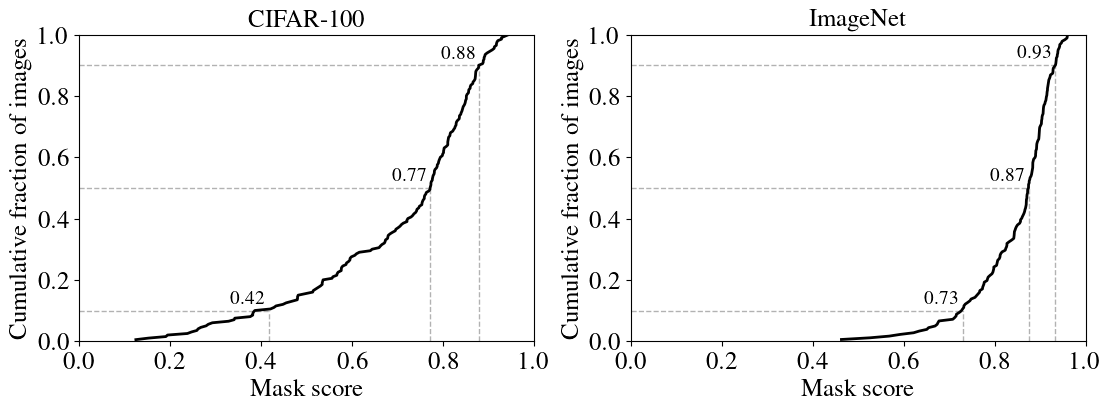

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import shutil

LATEX_AVAILABLE = shutil.which("latex") is not None

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times", "DejaVu Serif"],
    "axes.labelsize": 14,
    "axes.titlesize": 15,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

if LATEX_AVAILABLE:
    plt.rcParams.update({
        "text.usetex": True,
        "text.latex.preamble": r"\usepackage{amsmath}\usepackage{bm}",
    })
else:
    plt.rcParams.update({
        "text.usetex": False,
        "mathtext.fontset": "cm",
    })

label_fs = 18
tick_fs = 18
legend_fs = 15

imagenet_path = "../../analysis/csvs/ALL_vggnet_triplets_merged.csv"
cifar100_path = "../../results/cifar100/cifar100_segmented.csv"

df_imagenet = pd.read_csv(imagenet_path)
df_cifar100 = pd.read_csv(cifar100_path)

image_col = "image"
score_col = "score"

def prepare_scores(df):
    df = df[[image_col, score_col]].dropna()
    df[image_col] = df[image_col].astype(str)
    df = df.drop_duplicates(subset=image_col)
    scores = df[score_col].astype(float).to_numpy()
    scores.sort()
    return scores

scores_im = prepare_scores(df_imagenet)
scores_cf = prepare_scores(df_cifar100)

def plot_ecdf(ax, scores, title):
    n = len(scores)
    y = np.arange(1, n + 1) / n   # cumulative probability

    ax.plot(
        scores, 
        y, 
        linewidth=2.0,
        color="black",)

    qs = [0.10, 0.50, 0.90]
    qvals = np.quantile(scores, qs)

    for q, v in zip(qs, qvals):
        ax.hlines(
            y=q,
            xmin=0.0, xmax=v,
            linestyle="--", linewidth=1.0,
            alpha=0.3, color="black"
        )
        ax.vlines(
            x=v,
            ymin=0.0, ymax=q,
            linestyle="--", linewidth=1.0,
            alpha=0.3, color="black"
        )
        ax.text(v - 0.01, q + 0.01, f"{v:.2f}", fontsize=14, ha="right", va="bottom")

    ax.set_title(title, fontsize=label_fs)
    ax.set_xlabel("Mask score", fontsize=label_fs)
    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(0.0, 1.0)
    ax.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
    ax.tick_params(axis="both", labelsize=tick_fs)

    ax.set_ylabel("Cumulative fraction of images", fontsize=label_fs)

    # ax.grid(linestyle="--", linewidth=0.5, alpha=0.6)
    ax.spines["top"].set_visible(True)
    ax.spines["right"].set_visible(True)


fig, axes = plt.subplots(1, 2, figsize=(11, 4.0), sharex=False, sharey=False, constrained_layout=True)

plot_ecdf(axes[1], scores_im, "ImageNet")
plot_ecdf(axes[0], scores_cf, "CIFAR-100")

fig.savefig("masking_scores_ecdf_imagenet_vs_cifar100.pdf", bbox_inches="tight")
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Map results to paper terminology
plot_df = dist.copy()

plot_df["result_clean"] = plot_df["result_clean"].replace({
    "unsat": "Safe",
    "sat": "Unsafe",
    "timeout": "Unknown"
})

# Legend order
result_order = ["Safe", "Unsafe", "Unknown"]

plot_df["result_clean"] = pd.Categorical(
    plot_df["result_clean"],
    categories=result_order,
    ordered=True
)

plot_df = plot_df.sort_values(["score_bin", "result_clean"])


# Paper-style theme
sns.set_theme(style="whitegrid")

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "legend.fontsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "pdf.fonttype": 42
})


fig, ax = plt.subplots(figsize=(7.2,4.8))


palette = {
    "Safe": "#4C72B0",
    "Unsafe": "#DD8452",
    "Unknown": "#55A868"
}


sns.barplot(
    data=plot_df,
    x="score_bin",
    y="proportion",
    hue="result_clean",
    hue_order=result_order,
    palette=palette,
    ax=ax
)


ax.set_xlabel("Mask score")
ax.set_ylabel("Proportion of instances")
ax.set_title("Verification outcome vs mask score (ImageNet)", pad=10)


ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.6)
ax.grid(axis="x", visible=False)


ax.legend(title="Outcome")


plt.tight_layout()

plt.savefig("imagenet_score_vs_outcome_k50176.pdf", bbox_inches="tight")

plt.show()

NameError: name 'dist' is not defined